# 🌍 Reddit strategy audit: global dual momentum rotation

## 🧭 tl;dr

This notebook tests a Reddit-style dual-momentum rotation: use an absolute trend filter, compare trailing performance of US equities and developed ex-US equities, and rotate to long-duration bonds when the equity filter is off. The Reddit post reported **17.26% CAGR, −45% maximum drawdown, and 0.58 Sharpe**. We reproduce the idea with liquid ETF proxies and make the sample, rebalance schedule, and costs explicit.

> Educational research only. This is not financial advice. The goal is to understand a rule, not to promise a return.

<div style="border-left: 5px solid #10B981; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #ECFDF5; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>Follow the signal construction first. Then compare monthly rotation with a buy-and-hold benchmark, inspect the test split, and read the sensitivity results before drawing conclusions.</div>


## 📚 Source and research question

The Reddit post describes a leveraged dual-momentum backtest using a 200-day trend filter and relative momentum between US and international stocks, with bonds as the defensive asset. It reports 17.26% CAGR, −45% drawdown, and 0.58 Sharpe. Discussion in the thread points out that start dates, recent-period performance, and daily-checking/churn assumptions can materially change the result.

Source: [Reddit dual-momentum post](https://www.reddit.com/r/LETFs/comments/1jj4tad/leveraged_dual_momentum_backtest/).

This notebook uses SPY, EFA, and TLT as liquid, unlevered proxies. EFA begins after SPY, so the common sample is shorter than a backtest using index histories. That is a deliberate data-availability limitation, not something to hide.


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.metrics import calculate_metrics
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_dual_momentum_panel():
    try:
        panel = load_price_panel(["SPY", "EFA", "TLT"], "2003-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily closes"
    except Exception as exc:
        demo = make_demo_ohlcv(periods=5_800, seed=404, start="2003-01-01")["close"]
        panel = pd.DataFrame({"SPY": demo, "EFA": demo * 0.92, "TLT": demo * 1.08}, index=demo.index)
        source = f"deterministic demo close panel fallback ({type(exc).__name__})"
    return panel.dropna(), source


close, data_source = load_dual_momentum_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily closes
Observations: 5,787 | 2003-01-02 to 2025-12-31


,EFA,SPY,TLT
Date,,,
2003-01-02,17.562988,59.328991,38.777897
2003-01-03,17.580357,59.511387,38.867767
2003-01-06,17.797503,60.560257,38.764423
2003-01-07,17.519552,60.410431,38.903736
2003-01-08,17.281555,59.537483,39.097000


## 📜 Exact test rule

At the first trading day of each month:

1. **Absolute momentum filter:** if SPY is above its trailing 200-day simple moving average, the equity sleeve is eligible; otherwise use TLT.
2. **Relative momentum:** compare the prior 252-trading-day return of SPY and EFA.
3. If the filter is on, allocate 100% to whichever equity has the higher 252-day return.
4. If the filter is off, allocate 100% to TLT.
5. Hold the chosen asset until the next monthly rebalance.

All scores are shifted by one trading day before the decision and the portfolio backtester shifts the target weights one further bar before applying returns. This keeps the signal from using a return that has not yet been observed.


In [3]:

def reddit_dual_momentum_weights(close, absolute_window=200, relative_window=252):
    close = close[["SPY", "EFA", "TLT"]].astype(float)
    sma = close["SPY"].rolling(absolute_window, min_periods=absolute_window).mean().shift(1)
    relative_score = close[["SPY", "EFA"]].pct_change(relative_window).shift(1)
    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        if pd.isna(sma.loc[timestamp]) or relative_score.loc[timestamp].isna().any():
            continue
        if close.loc[timestamp, "SPY"] <= sma.loc[timestamp]:
            candidates.loc[timestamp, "TLT"] = 1.0
        else:
            winner = relative_score.loc[timestamp].idxmax()
            candidates.loc[timestamp, winner] = 1.0
    monthly = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    monthly.loc[month_start] = candidates.loc[month_start]
    return monthly.ffill().fillna(0.0)


weights = reddit_dual_momentum_weights(close)
portfolio = run_portfolio_backtest(close, weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
buy_hold = run_portfolio_backtest(close, pd.DataFrame({"SPY": 1.0, "EFA": 0.0, "TLT": 0.0}, index=close.index), transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
splits = split_time_series(close)
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Formal results

The table reports net returns after 10 basis points per unit of portfolio turnover. The benchmark is SPY buy and hold over the same common sample. Because the Reddit post may use different underlying indexes, leverage, and start dates, a numerical mismatch is expected; the useful comparison is whether the economic behavior survives under a transparent ETF implementation.


In [4]:

rows = []
for name, test_result in [("Reddit-style dual momentum", portfolio), ("SPY buy & hold", buy_hold)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(test_result, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
results_table = pd.DataFrame(rows).set_index(["strategy", "period"])
display(results_table[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "win_rate", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "win_rate": "{:.2%}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))


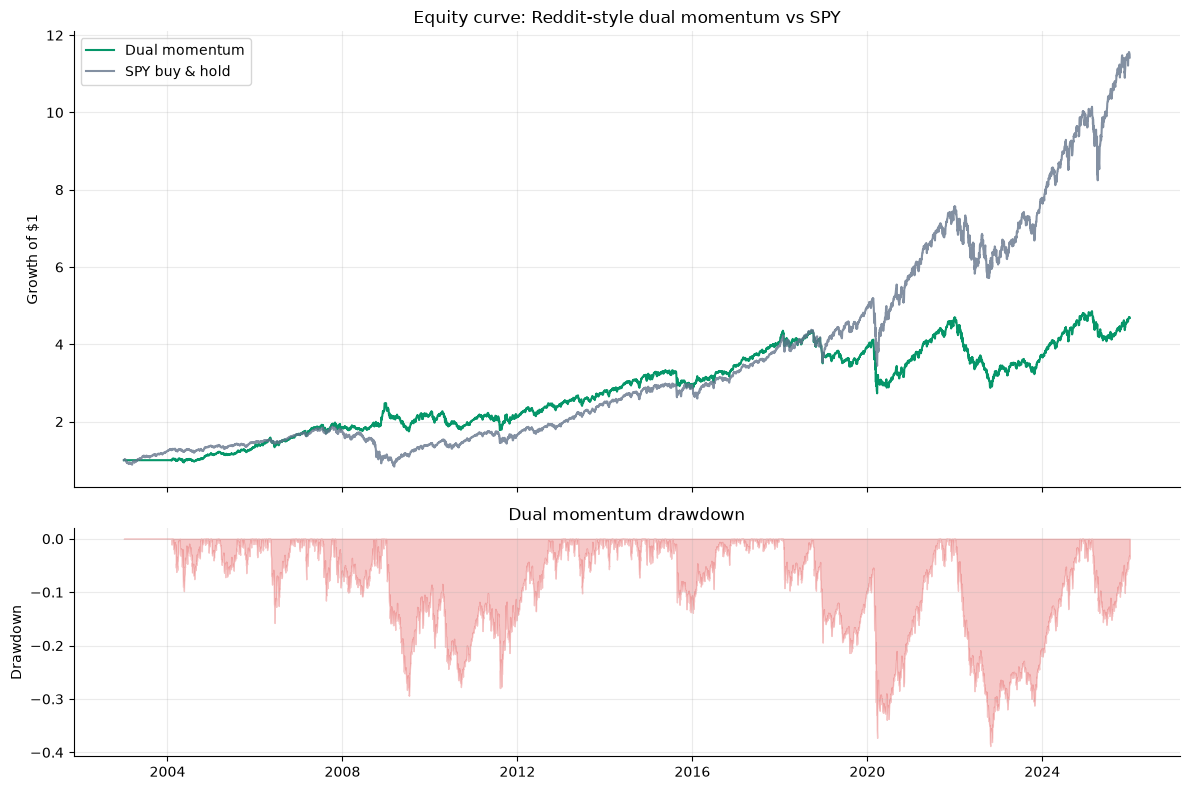

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(portfolio.frame.index, portfolio.frame.equity / portfolio.frame.equity.iloc[0], label="Dual momentum", color="#059669")
axes[0].plot(buy_hold.frame.index, buy_hold.frame.equity / buy_hold.frame.equity.iloc[0], label="SPY buy & hold", color="#64748B", alpha=0.8)
axes[0].set_title("Equity curve: Reddit-style dual momentum vs SPY")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(portfolio.frame.index, portfolio.frame.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Dual momentum drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🛡️ Regime and parameter checks

The most important fragility tests here are not just the best Sharpe. We check whether the result changes with the trend window, momentum lookback, transaction cost, and chronological period. Parameter combinations are ranked on validation only; the original 200/252 rule is evaluated on the untouched test period without retuning.


In [6]:

grid_rows = []
for absolute_window, relative_window in itertools.product([126, 200, 252], [126, 189, 252]):
    candidate_weights = reddit_dual_momentum_weights(close, absolute_window, relative_window)
    candidate = run_portfolio_backtest(close, candidate_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    validation_metrics = metrics_for_period(candidate, periods["validation"])
    test_metrics = metrics_for_period(candidate, periods["test"])
    grid_rows.append({"absolute_window": absolute_window, "relative_window": relative_window, "validation_sharpe": validation_metrics["sharpe_ratio"], "validation_return": validation_metrics["annualized_return"], "test_sharpe": test_metrics["sharpe_ratio"], "test_return": test_metrics["annualized_return"], "test_drawdown": test_metrics["max_drawdown"]})
sensitivity = pd.DataFrame(grid_rows).sort_values("validation_sharpe", ascending=False)
display(sensitivity.style.format({"validation_sharpe": "{:.2f}", "validation_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_return": "{:.2%}", "test_drawdown": "{:.2%}"}))


,absolute_window,relative_window,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
2,126,252,0.68,10.04%,0.32,3.85%,-38.81%
1,126,189,0.64,9.42%,0.22,2.32%,-38.81%
0,126,126,0.63,9.25%,0.24,2.61%,-38.81%
7,252,189,0.44,6.64%,0.28,3.20%,-38.81%
6,252,126,0.43,6.43%,0.30,3.72%,-38.81%
8,252,252,0.42,6.21%,0.32,4.00%,-38.81%
4,200,189,0.38,5.35%,0.19,1.72%,-38.81%
3,200,126,0.37,5.15%,0.21,2.02%,-38.81%
5,200,252,0.36,4.93%,0.29,3.27%,-38.81%


In [7]:

cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    cost_result = run_portfolio_backtest(close, weights, transaction_cost_bps=cost_bps, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    m = metrics_for_period(cost_result, periods["test"])
    cost_rows.append({"transaction_cost_bps": cost_bps, "test_return": m["annualized_return"], "test_sharpe": m["sharpe_ratio"], "test_drawdown": m["max_drawdown"], "test_turnover": m["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_drawdown": "{:.2%}", "test_turnover": "{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,3.86%,0.33,-38.44%,5.66
1,5,3.57%,0.31,-38.63%,5.66
2,10,3.27%,0.29,-38.81%,5.66
3,25,2.39%,0.23,-39.36%,5.66
4,50,0.94%,0.14,-40.28%,5.66


,EFA,SPY,TLT
Date,,,
2016,0.00,0.76,0.24
2017,0.50,0.50,0.00
2018,0.42,0.50,0.08
2019,0.00,0.76,0.24
2020,0.00,0.84,0.16
2021,0.00,1.00,0.00
2022,0.08,0.24,0.68
2023,0.76,0.16,0.08
2024,0.00,1.00,0.00


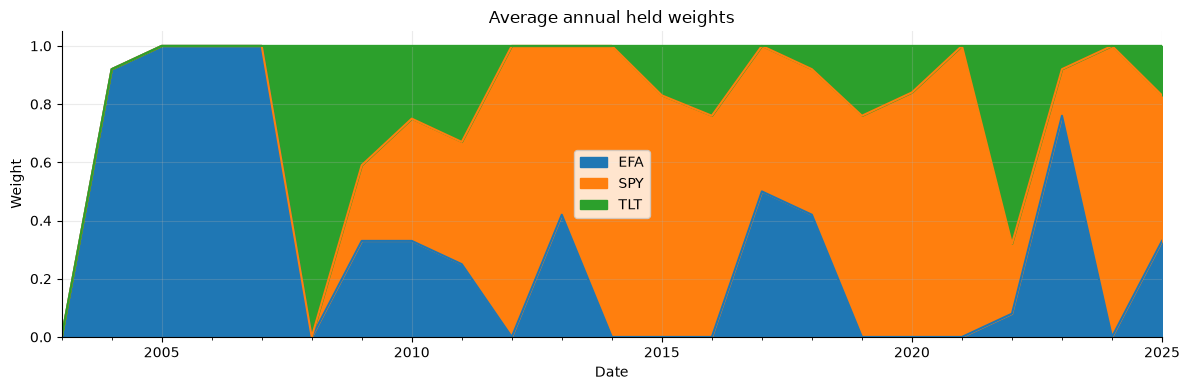

In [8]:

held_weights = portfolio.held_weights
allocation = held_weights.groupby(held_weights.index.to_period("Y")).mean().round(2)
display(allocation.tail(10))
allocation.plot.area(figsize=(12, 4), title="Average annual held weights")
plt.ylabel("Weight")
plt.tight_layout()


## ⚖️ What went well / what went wrong

### ✅ What went well

- The economic story is intuitive: momentum selects the stronger equity market while the trend filter attempts to reduce equity exposure during prolonged weakness.
- Monthly rebalancing keeps turnover and implementation complexity visible.
- The strategy can diversify a pure equity benchmark by holding TLT during some equity drawdowns.
- A common-sample ETF test makes the data limitation explicit instead of silently filling missing history with an index proxy.

### ⚠️ What went wrong or remains uncertain

- The Reddit headline is not an apples-to-apples benchmark: underlying indexes, leverage, start date, and execution rules may differ.
- Trend filters can exit late, whipsaw in sideways markets, and miss sharp rebounds.
- Bond exposure is not a guaranteed crisis hedge; rising-rate shocks can hurt both stocks and long-duration bonds.
- Selecting a window after seeing the full sensitivity table would overfit. The test-period result must remain tied to the pre-specified 200/252 rule.
- The thread itself highlights start-date dependence and recent underperformance. A high CAGR in one sample is not a stable expected return.

**Bottom line:** dual momentum is a credible, testable allocation rule, but the Reddit post’s return and Sharpe are sample-specific claims. The robust takeaway is the behavior across periods and costs, not the headline CAGR.
